In [1]:
# Plot BMR for every health variable

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter

In [3]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/bmr/"

In [4]:
# === Health variables ===
# COPD (chronic obstructive pulonary disease)
# LRI (lower respiratory infection)
# IHD (ischemic heart disease)
# DM2 (type 2 diabetes)
# LC (tracheal, bronchus, and lung cancer)
# Stroke
health_vars = ["COPD", "LRI", "IHD", "DM", "LC", "Stroke"]

In [7]:
def plot_bmr(da):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # === Use log scale for normalization ===
    vmin = da.min().item()
    vmax = da.max().item()
    cmap = plt.get_cmap("viridis")

    # avoid log(0) error
    if vmin <= 0:
        vmin = da.where(da > 0).min().item()

    norm = LogNorm(vmin=vmin, vmax=vmax)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Baseline Mortality Rate for {health_VAR}\n 1990-2009 av.", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("BMR per 100,000", fontsize=13)

    # Ticks at 1, 2, 5 × powers of 10
    locator = LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=12)
    col_bar.locator = locator
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    col_bar.ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()

    out_file = f"GBD_BMR_mean_{health_VAR}_1990-2009.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

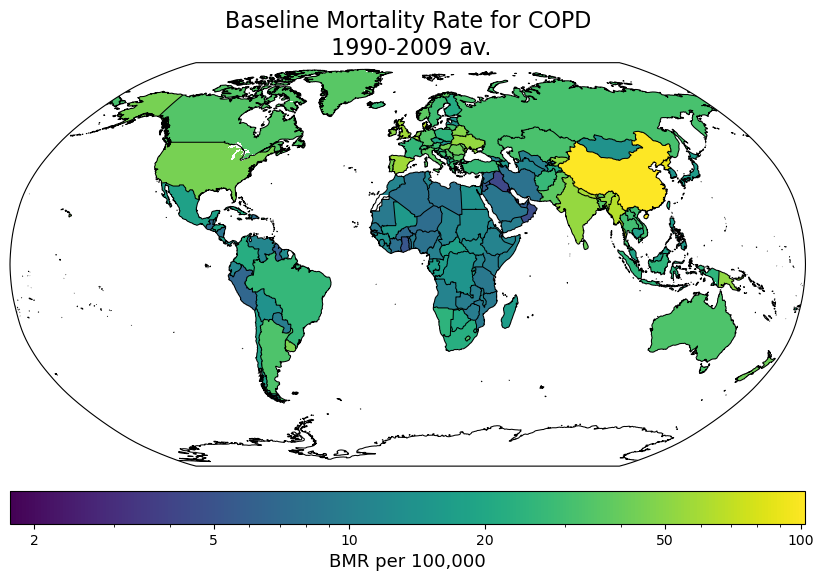

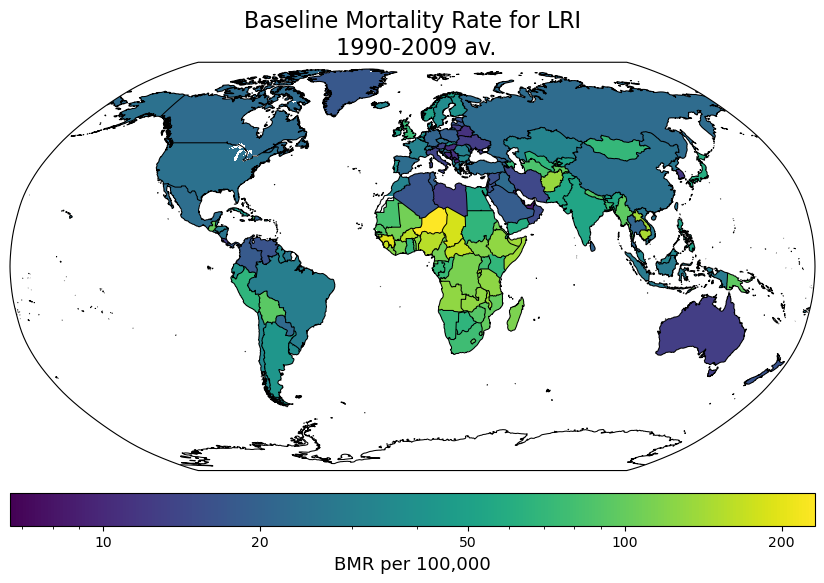

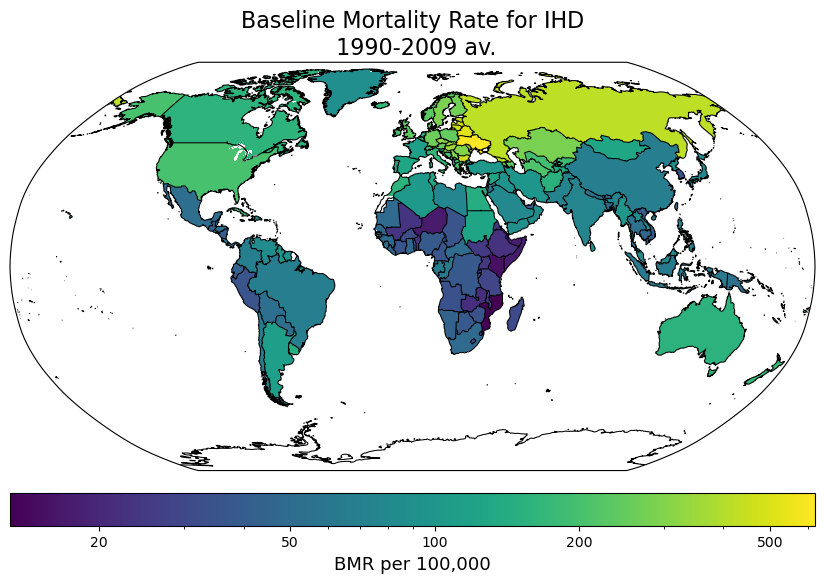

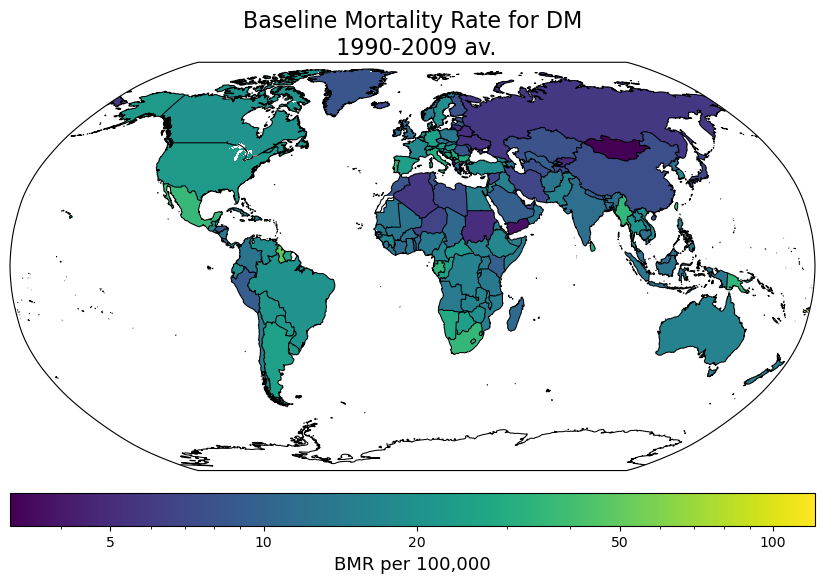

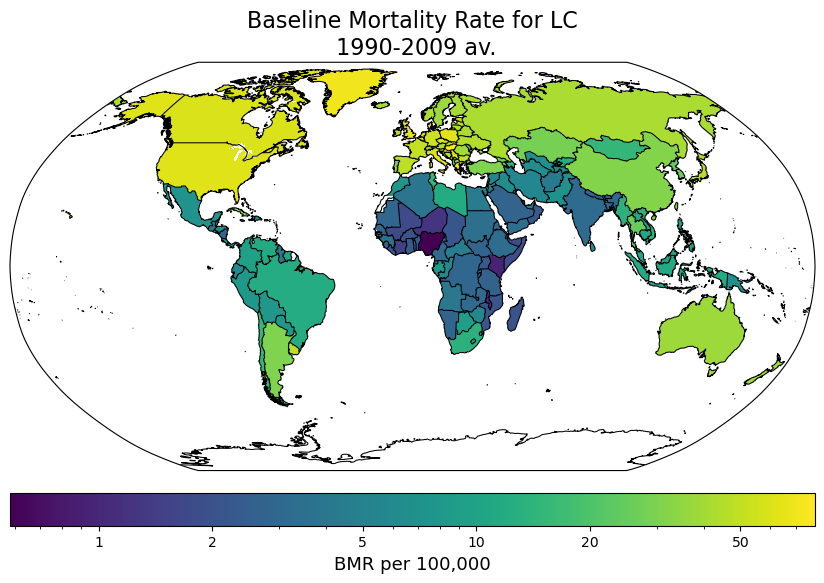

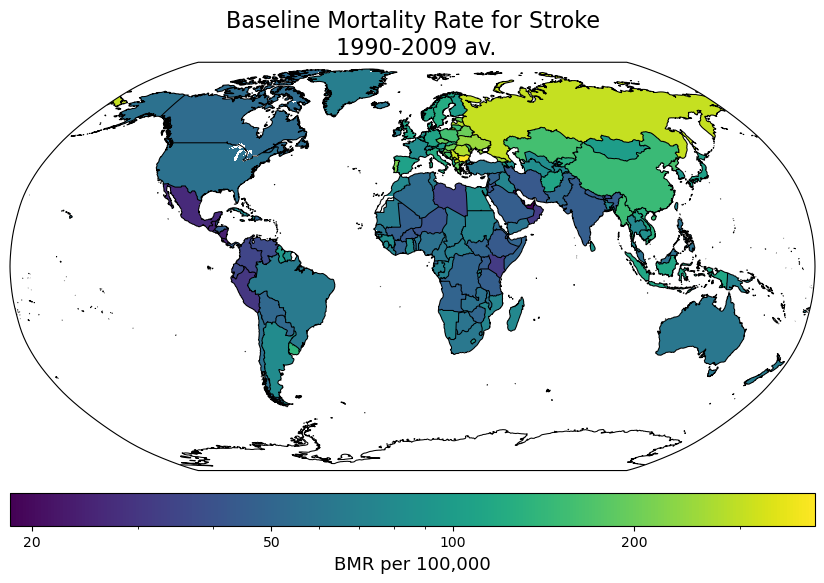

In [8]:
# === Main loop ===

for health_VAR in health_vars:
    bmr_file = f"GBD_BMR_Country_Mask_{health_VAR}_1990-2009.nc"
    bmr_path = os.path.join(BMR_DIR, bmr_file)
    bmr = xr.open_dataarray(bmr_path)

    # To be in units "per 100,000" and mask ocean
    bmr_mean = land_filter(bmr.sel(quantile="mean") * 100000)

    plot_bmr(bmr_mean)